### Objective

This notebook investigates the relationship between offshore storm characteristics derived from WHACS and observed shoreline change along the Canterbury coast. Storm metrics are aggregated in time and compared with shoreline change data to assess whether periods of increased storm intensity or frequency correspond to enhanced coastal erosion.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
storms = pd.read_csv(
    "WHACS_storm_metrics.csv",
    parse_dates=["start_time", "end_time"]
)

storms.head()


,start_time,end_time,duration_hours,peak_Hs,mean_direction
0,1999-01-01 02:00:00,1999-01-02 13:00:00,35.0,2.882,158.202158
1,1999-01-07 22:00:00,1999-01-09 18:00:00,44.0,3.748,186.532960
2,1999-01-13 21:00:00,1999-01-15 09:00:00,36.0,3.286,106.935266
3,1999-01-26 07:00:00,1999-01-27 00:00:00,17.0,2.830,85.938343
4,1999-01-27 04:00:00,1999-01-27 19:00:00,15.0,2.680,149.767015


In [3]:
shoreline = pd.read_csv(
    "/Users/blesso/WHACS/analysis/shoreline_change_all_transects.csv",
    
)

shoreline.head()
shoreline.info()






<class 'pandas.core.frame.DataFrame'>
RangeIndex: 926333 entries, 0 to 926332
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   site_id           926333 non-null  object 
 1   transect_id       926333 non-null  object 
 2   month             926333 non-null  object 
 3   shoreline_pos     926333 non-null  float64
 4   n_in_month        926333 non-null  int64  
 5   shoreline_change  922744 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 42.4+ MB


In [4]:
shoreline["month"].dtype
shoreline["month"].head()
shoreline["month"].tail()


926328    2025-07-01
926329    2025-08-01
926330    2025-09-01
926331    2025-10-01
926332    2025-11-01
Name: month, dtype: object

In [12]:
shoreline["month"] = pd.to_datetime(shoreline["month"])


In [13]:
shoreline_monthly = (
    shoreline
    .groupby("month")
    .agg(
        mean_shoreline_change=("shoreline_change", "mean")
    )
    .reset_index()
)

shoreline_monthly.head()


,month,mean_shoreline_change
0,1999-07-01,NaN
1,1999-08-01,2.105517
2,1999-09-01,3.266016
3,1999-10-01,3.780714
4,1999-11-01,1.193659


In [15]:
storms = pd.read_csv(
    "/Users/blesso/WHACS/analysis/WHACS_storm_metrics.csv"
)

storms.columns


Index(['start_time', 'end_time', 'duration_hours', 'peak_Hs',
       'mean_direction'],
      dtype='object')

In [16]:
storms = pd.read_csv(
    "/Users/blesso/WHACS/analysis/WHACS_storm_metrics.csv"
)

storms["start_time"] = pd.to_datetime(storms["start_time"])
storms.head()


,start_time,end_time,duration_hours,peak_Hs,mean_direction
0,1999-01-01 02:00:00,1999-01-02 13:00:00,35.0,2.882,158.202158
1,1999-01-07 22:00:00,1999-01-09 18:00:00,44.0,3.748,186.532960
2,1999-01-13 21:00:00,1999-01-15 09:00:00,36.0,3.286,106.935266
3,1999-01-26 07:00:00,1999-01-27 00:00:00,17.0,2.830,85.938343
4,1999-01-27 04:00:00,1999-01-27 19:00:00,15.0,2.680,149.767015


In [17]:
storms["month"] = storms["start_time"].dt.to_period("M").dt.to_timestamp()


In [18]:
monthly_storms = (
    storms
    .groupby("month")
    .agg(
        storm_count=("peak_Hs", "count"),
        mean_peak_Hs=("peak_Hs", "mean"),
        max_peak_Hs=("peak_Hs", "max"),
        mean_duration=("duration_hours", "mean")
    )
    .reset_index()
)

monthly_storms.head()


,month,storm_count,mean_peak_Hs,max_peak_Hs,mean_duration
0,1999-01-01,6,3.282000,4.266,37.666667
1,1999-02-01,7,3.594571,6.796,42.714286
2,1999-03-01,8,3.042000,4.102,31.500000
3,1999-04-01,5,3.674000,6.418,80.800000
4,1999-05-01,10,4.068800,6.926,47.900000


In [19]:
merged = pd.merge(
    shoreline_monthly,
    monthly_storms,
    on="month",
    how="inner"
)

merged.head()


,month,mean_shoreline_change,storm_count,mean_peak_Hs,max_peak_Hs,mean_duration
0,1999-07-01,NaN,5,4.487600,6.812,122.400000
1,1999-08-01,2.105517,6,4.098000,6.500,86.166667
2,1999-09-01,3.266016,12,3.395000,5.302,32.000000
3,1999-10-01,3.780714,10,3.405600,4.918,51.400000
4,1999-11-01,1.193659,6,4.128667,5.612,75.833333


In [20]:
merged[[
    "mean_shoreline_change",
    "storm_count",
    "mean_peak_Hs",
    "max_peak_Hs",
    "mean_duration"
]].corr()


,mean_shoreline_change,storm_count,mean_peak_Hs,max_peak_Hs,mean_duration
mean_shoreline_change,1.000000,0.287118,-0.303976,-0.259488,-0.333113
storm_count,0.287118,1.000000,-0.621439,-0.251623,-0.674485
mean_peak_Hs,-0.303976,-0.621439,1.000000,0.639672,0.826222
max_peak_Hs,-0.259488,-0.251623,0.639672,1.000000,0.429280
mean_duration,-0.333113,-0.674485,0.826222,0.429280,1.000000


In [21]:
plot_df = merged.dropna(subset=["mean_shoreline_change"])


Shoreline Change VS Strom Frequency(WHACS)

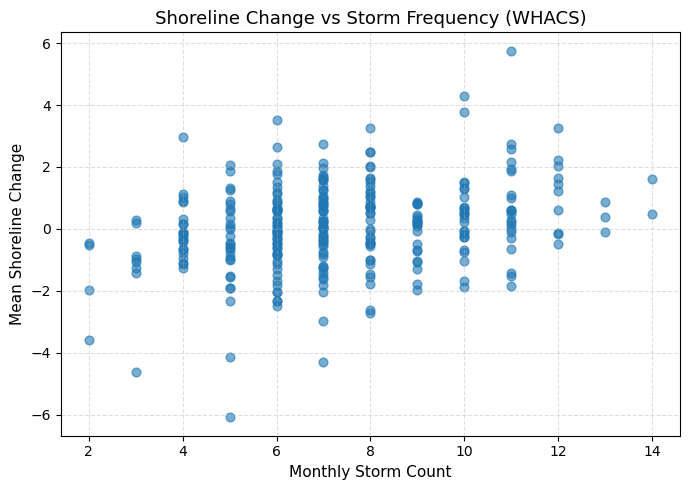

In [23]:
plt.figure(figsize=(7,5))
plt.scatter(
    plot_df["storm_count"],
    plot_df["mean_shoreline_change"],
    alpha=0.6,
    s=40
)

plt.xlabel("Monthly Storm Count", fontsize=11)
plt.ylabel("Mean Shoreline Change", fontsize=11)
plt.title("Shoreline Change vs Storm Frequency (WHACS)", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



This plot shows the relationship between monthly storm frequency and mean shoreline change. The wide scatter and weak trend suggest that increases in the number of storms alone do not consistently lead to greater erosion or accretion. While some higher storm-count months coincide with larger shoreline changes, the overall relationship appears weak, indicating that storm frequency by itself is not the dominant control on shoreline response.

Shoreline Change vs Strom Intensity (max peak Hs)

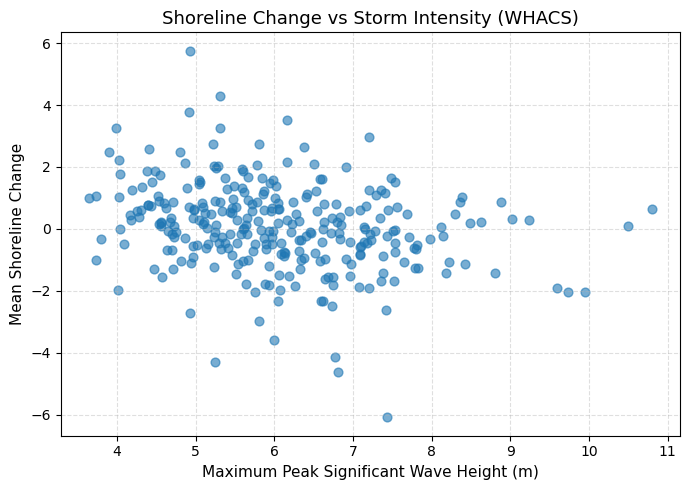

In [24]:
plt.figure(figsize=(7,5))
plt.scatter(
    plot_df["max_peak_Hs"],
    plot_df["mean_shoreline_change"],
    alpha=0.6,
    s=40
)

plt.xlabel("Maximum Peak Significant Wave Height (m)", fontsize=11)
plt.ylabel("Mean Shoreline Change", fontsize=11)
plt.title("Shoreline Change vs Storm Intensity (WHACS)", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


This scatter plot compares shoreline change with maximum peak significant wave height. A slight negative tendency is visible, where higher-intensity storms are more often associated with shoreline retreat. However, the spread remains large, showing that intense storms do not always result in strong erosion, and other factors such as storm duration, direction, and antecedent conditions likely play an important role.

Shoreline Change vs Duration

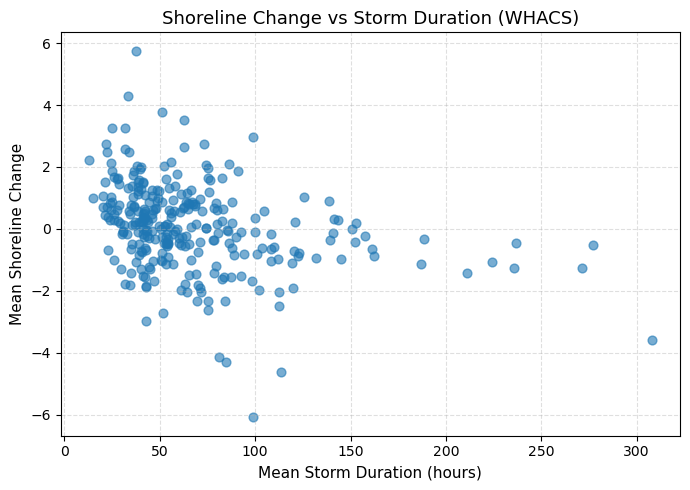

In [25]:
plt.figure(figsize=(7,5))
plt.scatter(
    plot_df["mean_duration"],
    plot_df["mean_shoreline_change"],
    alpha=0.6,
    s=40
)

plt.xlabel("Mean Storm Duration (hours)", fontsize=11)
plt.ylabel("Mean Shoreline Change", fontsize=11)
plt.title("Shoreline Change vs Storm Duration (WHACS)", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


This plot highlights the relationship between mean storm duration and shoreline change. Longer-duration storms tend to cluster toward more negative shoreline change values, suggesting that sustained wave energy has a stronger erosive impact than short-lived events. Despite this tendency, variability remains high, reinforcing that shoreline response is influenced by multiple interacting storm characteristics.

In [26]:
storms = pd.read_csv(
    "WHACS_storms_with_types.csv",
    parse_dates=["start_time", "end_time"]
)

shoreline = pd.read_csv(
    "shoreline_change_all_transects.csv"
)


In [27]:
storms["month"] = storms["start_time"].dt.to_period("M").dt.to_timestamp()
shoreline["month"] = pd.to_datetime(shoreline["month"])


In [28]:
shoreline_monthly = (
    shoreline
    .groupby("month")
    .agg(mean_shoreline_change=("shoreline_change", "mean"))
    .reset_index()
)

shoreline_monthly.head()


,month,mean_shoreline_change
0,1999-07-01,NaN
1,1999-08-01,2.105517
2,1999-09-01,3.266016
3,1999-10-01,3.780714
4,1999-11-01,1.193659


In [29]:
storms_monthly = (
    storms
    .groupby(["month", "storm_type_name"])
    .agg(
        storm_count=("peak_Hs", "count"),
        mean_peak_Hs=("peak_Hs", "mean"),
        max_peak_Hs=("peak_Hs", "max"),
        mean_duration=("duration_hours", "mean")
    )
    .reset_index()
)

storms_monthly.head()


,month,storm_type_name,storm_count,mean_peak_Hs,max_peak_Hs,mean_duration
0,1999-01-01,Moderate Short-Duration,4,3.394,4.266,43.25
1,1999-01-01,Short-Lived Directional,2,3.058,3.286,26.50
2,1999-02-01,Moderate Short-Duration,2,3.679,3.816,31.00
3,1999-02-01,Severe Long-Duration,1,6.796,6.796,191.00
4,1999-02-01,Short-Lived Directional,4,2.752,3.234,11.50


In [30]:
merged = pd.merge(
    storms_monthly,
    shoreline_monthly,
    on="month",
    how="inner"
)

merged.head()


,month,storm_type_name,storm_count,mean_peak_Hs,max_peak_Hs,mean_duration,mean_shoreline_change
0,1999-07-01,Moderate Short-Duration,1,3.286000,3.286,34.000000,NaN
1,1999-07-01,Severe Long-Duration,3,5.535333,6.812,191.666667,NaN
2,1999-07-01,Short-Lived Directional,1,2.546000,2.546,3.000000,NaN
3,1999-08-01,Moderate Short-Duration,1,3.368000,3.368,70.000000,2.105517
4,1999-08-01,Severe Long-Duration,2,5.788000,6.500,172.000000,2.105517


<Figure size 800x500 with 0 Axes>

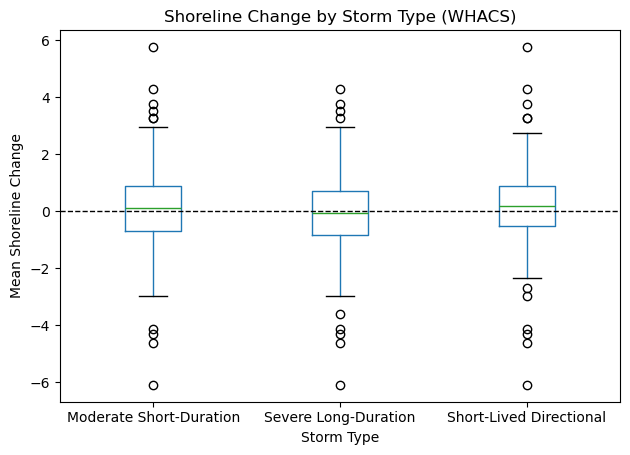

In [31]:
plt.figure(figsize=(8,5))

merged.boxplot(
    column="mean_shoreline_change",
    by="storm_type_name",
    grid=False
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Shoreline Change by Storm Type (WHACS)")
plt.suptitle("")
plt.ylabel("Mean Shoreline Change")
plt.xlabel("Storm Type")
plt.tight_layout()
plt.show()


In [33]:
erosion_summary = (
    merged
    .groupby("storm_type_name")["mean_shoreline_change"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        min="min",
        max="max"
    )
    .round(3)
)

erosion_summary


,count,mean,median,std,q25,q75,min,max
storm_type_name,,,,,,,,
Moderate Short-Duration,272,0.098,0.111,1.423,-0.690,0.872,-6.091,5.757
Severe Long-Duration,245,-0.056,-0.067,1.381,-0.828,0.728,-6.091,4.294
Short-Lived Directional,245,0.150,0.180,1.395,-0.531,0.878,-6.091,5.757


In [34]:
erosion_summary.to_csv(
    "WHACS_storm_type_erosion_summary.csv"
)
